In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math

$$
L(M) = \left(\sum_i^m q_{i\curvearrowright}\right) \log\left(\sum_i^m q_{i\curvearrowright}\right)  - 2 \sum_i^m q_{i\curvearrowright} \log(q_{i\curvearrowright}) + \sum_i^m \left(q_{i\curvearrowright} + \sum_{\alpha \in i} p_\alpha\right) \log\left(q_{i\curvearrowright} + \sum_{\alpha \in i} p_\alpha\right) + H[p_\alpha]
$$

In [ ]:
# ==============================
# ===== CODICE DI LORENZO ======
# ==============================

def shannonEntropy(probabilities):
    h = 0
    for p in probabilities:
        if p > 0:
            h -= p * math.log2(p)
    return h

def mapEquation(G, partition, equilibriumProbabilities, tau=0.15):
    # dict containing the modules
    modules = set(partition.values())
    n = G.number_of_nodes()
    q_out = {m: 0.0 for m in modules}  # q_i for each module
    p_sum = {m: 0.0 for m in modules}  # \sum_\alpha \in i p_\alpha for each i
    mod_nodes = {m: [] for m in modules} # List of nodes in each module

    # Let's populate these dicts
    for u in G.nodes():
        # Module of node u
        m_u = partition[u]
        # Its equilibrium probability
        pr_u = equilibriumProbabilities[u]
        
        p_sum[m_u] += pr_u
        mod_nodes[m_u].append(u)
        
        deg_u = G.degree(u, weight='weight')
        if deg_u > 0:
            for v in G.neighbors(u):
                m_v = partition[v]
                if m_u != m_v: 
                    # Get the weight of the edge (u, v), if one is there, otherwise default to 1
                    w_uv = G[u][v].get('weight', 1.0)
                    # Using the formula in the paper 
                    q_out[m_u] += (1-tau)*(pr_u / deg_u) * w_uv 
    for m in modules:
        n_i = len(mod_nodes[m]) 
        teleport_flow = tau * (n - n_i) / (n - 1) * p_sum[m]
        q_out[m] += teleport_flow

    # Now let's compute the first term for the map equation
    total_q = sum(q_out.values())
    if total_q < 1e-12:   # regularization to avoid log(0), 0 log(0) = 0
        L_index = 0.0
    else:
        Q_probs = [val / total_q for val in q_out.values()]
        L_index = total_q * shannonEntropy(Q_probs)

    # Computing the second term for the map equation
    L_module = 0.0
    for m in modules:
        p_circle = p_sum[m] + q_out[m]
        
        if p_circle > 1e-12:
            probs_internal = [equilibriumProbabilities[u] / p_circle for u in mod_nodes[m]]
            probs_internal.append(q_out[m] / p_circle)
            L_module += p_circle * shannonEntropy(probs_internal)
            
    return L_index + L_module

# Helper function to draw the graph with a partition
def draw_partition(G, partition_dict, title):
    pos = nx.spring_layout(G, seed=42)
    node_colors = [partition_dict[n] for n in G.nodes()]

    plt.figure(figsize=(10, 7))
    plt.title(title)
    nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.tab10, node_size=500, edge_color="gray", font_color="black")
    plt.show()

In [856]:
def greedyMerge(G : nx.Graph, partition : dict = None, equilibriumProbabilities : list = None, 
                tau : float = 0.15, n_iter : int = 100, tol : float = 1e-6, save_history : bool = False):
    """  
    Greedy merge algorithm for community detection based on the map equation. Computational complexity O(n^2)
    > M. Rosvall and C. T. Bergstrom, "Maps of random walks on complex networks reveal community structure", 2008.

    Parameters:
    ----------
    G : nx.Graph
        The input graph for which we want to find the community structure.
    partition : dict, optional
        A dictionary mapping each node to its initial module. If None, each node starts in its own module.
    equilibriumProbabilities : list, optional
        A list of stationary probabilities for each node. If None, it will be computed using PageRank.
    tau : float, optional
        The teleportation probability for the random walk. Default is 0.15.
    n_iter : int, optional
        The number of iterations for the greedy merge process. Default is 100.
    tol : float, optional
        The tolerance for convergence. If the improvement in L is less than tol, the algorithm will stop. Default is 1e-6.
    save_history : bool, optional
        Whether to save the history of L values during the merging process. Default is False.
    
    Returns:
    -------
    dict
        A dictionary mapping each node to its final module after the greedy merge process.
    list (optional)
        If save_history is True, returns a list of L values at each step of the merging process.
    """
    
    # Initialize partitions if not provided
    if partition is None:
        partition = {u: u for u in G.nodes()}

    # Compute stationary probabilities if not provided
    if equilibriumProbabilities is None:
        equilibriumProbabilities = list(nx.pagerank(G).values())

    L_values = []
    L_values.append(mapEquation(G, partition, equilibriumProbabilities, tau))

    # We can shuffle node order to avoid bias
    #shuffle_nodes = list(G.nodes())
    #np.random.shuffle(shuffle_nodes)

    best_partition = partition
    for _ in range(n_iter):
        best_L = float('inf')
        trial_partition = None

        for u in G.nodes():
            current_module = best_partition[u]
            # For increase efficiency, we only consider merging with neighbors of u
            # but we could also consider merging with any other node in the network
            for v in G.neighbors(u):
                if u != v and best_partition[v] != current_module:

                    # Try to merge 
                    trial_partition = best_partition.copy()
                    trial_partition[v] = current_module
                    L = mapEquation(G, trial_partition, equilibriumProbabilities, tau)

                    if L < best_L:
                        best_L = L
                        best_partition = trial_partition
                        L_values.append(best_L)       
                
        if len(L_values) > 1 and L_values[-1] - L_values[-2] < tol: break
    if save_history:
        return best_partition, L_values
    return best_partition

def simulatedAnnealing(G : nx.Graph, partition : dict, equilibriumProbabilities : list = None, tau : float = 0.15, n_iter : int = 10,
                       T_max : float = 1.0, T_min : float = 1e-3, cooling_rate : float = 0.99, tol : float = 1e-6, save_history : bool = False):
    """  
    Simulated annealing algorithm for community detection based on the map equation.
    > M. Rosvall and C. T. Bergstrom, "Maps of random walks on complex networks reveal community structure", 2008.

    Parameters:
    ----------
    G : nx.Graph
        The input graph for which we want to find the community structure.
    partition : dict
        A dictionary mapping each node to its initial module.
    equilibriumProbabilities : list
        A list of stationary probabilities for each node.
    tau : float, optional
        The teleportation probability for the random walk. Default is 0.15.
    n_iter : int, optional
        The number of attempted moves at each temperature step. Default is 10.
    T_max : float, optional
        The initial temperature for the simulated annealing process. Default is 1.0.
    T_min : float, optional
        The minimum temperature for the simulated annealing process. Default is 1e-3.
    cooling_rate : float, optional
        The cooling rate for the simulated annealing process. Default is 0.99.
    tol : float, optional
        The tolerance for convergence. If the improvement in L is less than tol, the algorithm will stop. Default is 1e-6.
    save_history : bool, optional
        Whether to save the history of L values during the merging process. Default is False.
    
    Returns:
    -------
    dict
        A dictionary mapping each node to its final module after the simulated annealing process.
    list (optional)
        If save_history is True, returns a list of L values at each step of the merging process.
    """
    
    # Compute probabilities if not provided
    if equilibriumProbabilities is None:
        equilibriumProbabilities = list(nx.pagerank(G).values())

    L_values = []
    current_partition = partition.copy()
    current_L = mapEquation(G, current_partition, equilibriumProbabilities, tau)

    best_partition = current_partition.copy()
    best_L = current_L
    if save_history: L_values.append(current_L)

    T = T_max
    while T > T_min:
        for _ in range(n_iter):
            # Pick a random node u and its neighbor v
            u = np.random.choice(list(G.nodes()))
            neighbors = list(G.neighbors(u))
            if not neighbors:
                continue
            v = np.random.choice(neighbors)

            # Check if the neighbor u belongs to a different module
            target_module = current_partition[v]
            current_module = current_partition[u]
            if current_module == target_module:
                continue
            
            trial_partition = current_partition.copy()
            trial_partition[u] = target_module
            trial_L = mapEquation(G, trial_partition, equilibriumProbabilities, tau)
            delta_L = trial_L - current_L

            # Accept or reject the move based on the Metropolis criterion
            if delta_L < 0 or np.random.rand() < math.exp(-delta_L / T):
                current_partition = trial_partition
                current_L = trial_L

                if current_L < best_L:
                    best_L = current_L
                    best_partition = current_partition.copy()
            if save_history: L_values.append(current_L)

        T *= cooling_rate
        
    if save_history: return best_partition, L_values
    return best_partition

Final partitions: m = 3
After greedy search: L = 4.5769 bits


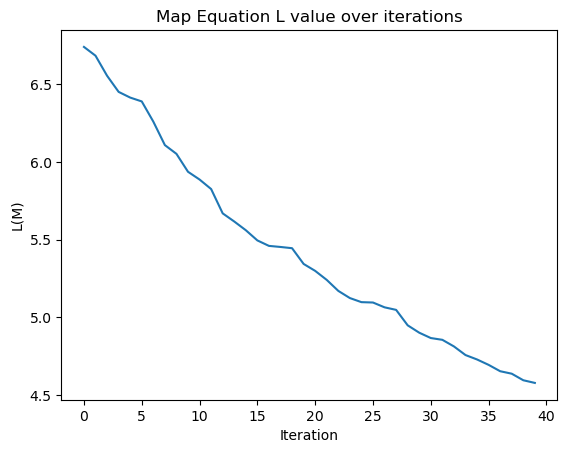

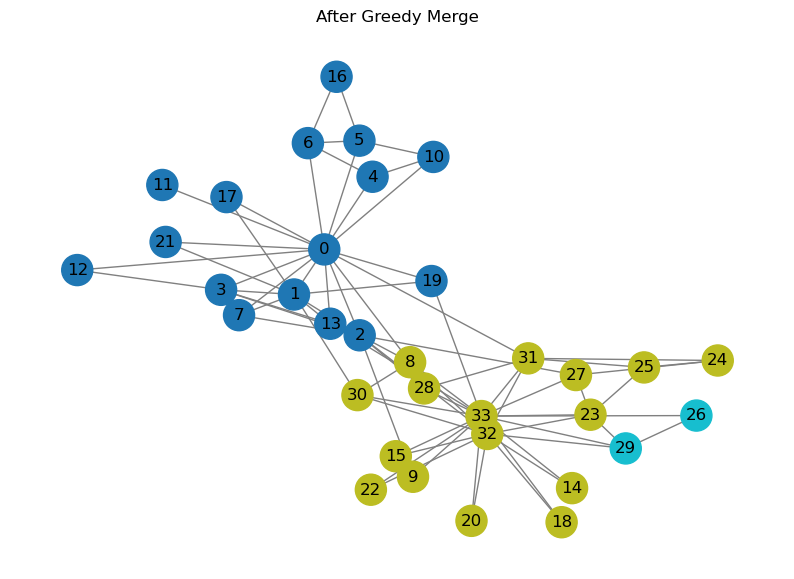

In [857]:
G = nx.karate_club_graph()
#G = nx.gaussian_random_partition_graph(n = 50, s = 10, v = 3, p_in = 0.8, p_out = 0.05, seed=123)
greedy_partition, L_history = greedyMerge(G, n_iter=100, save_history=True)

print("Final partitions: m =", len(set(greedy_partition.values())))
print(f"After greedy search: L = {L_history[-1]:.4f} bits")

plt.plot(L_history)
plt.xlabel('Iteration')
plt.ylabel('L(M)')
plt.title('Map Equation L value over iterations')
plt.show()

draw_partition(G, greedy_partition, title="After Greedy Merge")

Final partitions: m = 2
After simulated annealing: L = 4.5466 bits


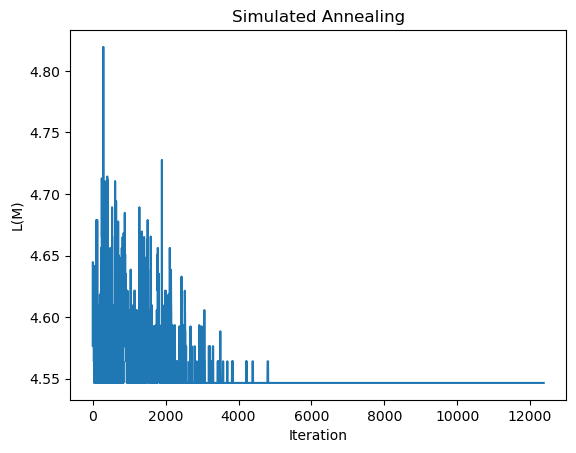

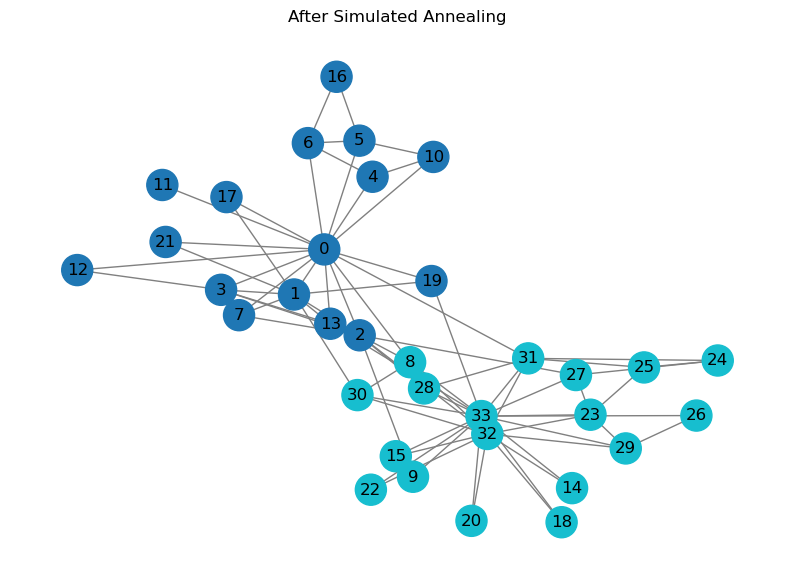

In [859]:
# We could also re-heat the system to try different local minima
# (for this small graph it doesn't make much sense)

# TODO: we only need \Delta L, we don't need to recompute L each time
# TODO: for greedy search we take nodes in order. We coud randomize or check neighbors first

final_partition, L_history_sa = simulatedAnnealing(G, greedy_partition, n_iter=200, T_max=0.05, T_min=1e-4, cooling_rate=0.99, save_history=True)
print("Final partitions: m =", len(set(final_partition.values())))
print(f"After simulated annealing: L = {mapEquation(G, final_partition, list(nx.pagerank(G).values()), tau=0.15):.4f} bits")

plt.plot(L_history_sa)
plt.xlabel('Iteration')
plt.ylabel('L(M)')
plt.title('Simulated Annealing')
plt.show()

draw_partition(G, final_partition, title="After Simulated Annealing")